<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EC%9D%91%EC%9A%A9_10%EC%B0%A8%EC%8B%9C_02_pytorch_%ED%95%B4%EC%84%9D%EA%B0%80%EB%8A%A5%EC%84%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch            # PyTorch 핵심 라이브러리
import torch.nn as nn   # 신경망 레이어 정의
import torch.nn.functional as F # 신경망 함수 (ReLU, Loss 등)
import torch.optim as optim # 옵티마이저 (학습 알고리즘)
from torch.utils.data import DataLoader # 배치 데이터 로드
from torchvision import datasets, transforms # 이미지 데이터셋 및 전처리


import matplotlib.pyplot as plt # 데이터 시각화
import numpy as np              # 수치 계산 및 배열 처리

In [51]:
np.random.seed(123)
torch.manual_seed(123)

In [52]:
class ConvNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.cn1 = nn.Conv2d(1, 16, 3, 1)   # 1(흑백)입력, 16채널 출력, kernel_size = 3, stride = 1
        self.cn2 = nn.Conv2d(16, 32, 3, 1)
        self.dp1 = nn.Dropout2d(0, 10) #10% 비율로 무작위 비활성화
        self.dp2 = nn.Dropout1d(0, 25)
        self.fc1 = nn.Linear(4608, 64)  # (12*12*32)차원 입력
        self.fc2 = nn.Linear(64, 10)  # 64차원 입력 >> 10차원 출력(10개 클래스)

    def forward(self, x):
        x = self.cn1(x)
        x = F.relu(x)
        x = self.cn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)  # 2*2 max pooling (크기 절반 감소)
        x = self.dp1(x)
        x = torch.flatten(x, 1)     # 채널 제외하고 평탄화 (2d >> 1d)
        # (N, C, H, W >> (N, C*H*W)
        x = self.fc1(x)
        x = self.dp2(x)
        x= self.fc2(x)      # 두번째 완전 연결츨 (최종 완전 연결층:클래스 정수)
        op = F.log_softmax(x, dim=1)
        # 로그 소프트맥스 : 최종 클래스 로그 확률 출력
        return op

In [53]:
from torch.nn.modules import loss
def train(model, device, train_dataloader, optim, epoch):

    model.train()

    for b_i, (X,y) in enumerate(train_dataloader):
        X,y = X.to(device), y.to(device)

        optim.zero_grad()
        # 이전 step 누적된 기울기 0으로 초기화
        pred_prob = model(X)
        # 순전파 : 모델의 예측값 (로그 확률) 계산

        loss = F.nll_loss(pred_prob, y)
        # 손실계산 : negative log-likelihood(log softmax 출력과 함께 사용)(**)

        loss.backward()
        optim.step()    # 기울기 >> 파라미터 업데이트

        if b_i % 10 == 0:
            print('epoch: {} [{}/{} ({:.0f}%)]\t training loss: {:.4f}'.format(
                epoch, b_i * len(X), len(train_dataloader.dataset),
                100. * b_i / len(train_dataloader), loss.item())
            # 진행률 표시 위한 현재 데이터 수, 전체 데이터 수, 현재 배치 진행률, 손실값 출력
                  )

In [54]:
def test(model, device, test_dataloader):
    model.eval()
    loss = 0
    success = 0

    # 기울기 계산 비활성화
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)

            pred_prob = model(X)

            loss += F.nll_loss(pred_prob, y, reduction='sum').item()
            # 배치 손실 계산 >> 전체 손실에 합산

            pred = pred_prob.argmax(dim=1, keepdim=True)
            # 예측 확률이 가장 높은 클래스 인덴스 >> 최종 예측 선택

            success += pred.eq(y.view_as(pred)).sum().item()
            # 예측과 정답 비교 (eq : equivalent) 맞은 개수를 success 누적(합)

    loss /= len(test_dataloader.dataset)
    # 전체 데이터 셋 크기로 나누어 평균 손실 계산

    # test 결과 (평균 손실, 정확도) 출력
    print('Test dataset : Overall Loss : {:.4f}, Overall Accuracy : {} / {} ({:.0f}%)\n'.format(
        loss, success, len(test_dataloader.dataset),
        100. * success / len(test_dataloader.dataset)
    ))

In [55]:
from random import shuffle

# 훈련용 데이터 로더
train_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=True, download=True,
                   transform = transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=32, shuffle=True
)

test_dataloader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True,
                   transform = transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=500, shuffle=False
)

In [56]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = ConvNet().to(device)
optimizer = optim.Adadelta(model.parameters(), lr=0.5)

In [57]:
for epoch in range(1,2):
    train(model, device, train_dataloader, optimizer, epoch)
    test(model, device, test_dataloader)

epoch: 1 [0/60000 (0%)]	 training loss: 2.3361
epoch: 1 [320/60000 (1%)]	 training loss: 1.5964
epoch: 1 [640/60000 (1%)]	 training loss: 0.5966
epoch: 1 [960/60000 (2%)]	 training loss: 0.8200
epoch: 1 [1280/60000 (2%)]	 training loss: 0.1358
epoch: 1 [1600/60000 (3%)]	 training loss: 0.2511
epoch: 1 [1920/60000 (3%)]	 training loss: 0.5842
epoch: 1 [2240/60000 (4%)]	 training loss: 0.2378
epoch: 1 [2560/60000 (4%)]	 training loss: 0.4771
epoch: 1 [2880/60000 (5%)]	 training loss: 0.3487
epoch: 1 [3200/60000 (5%)]	 training loss: 0.2472
epoch: 1 [3520/60000 (6%)]	 training loss: 0.3467
epoch: 1 [3840/60000 (6%)]	 training loss: 0.1384
epoch: 1 [4160/60000 (7%)]	 training loss: 0.1526
epoch: 1 [4480/60000 (7%)]	 training loss: 0.1565
epoch: 1 [4800/60000 (8%)]	 training loss: 0.1550
epoch: 1 [5120/60000 (9%)]	 training loss: 0.2320
epoch: 1 [5440/60000 (9%)]	 training loss: 0.1476
epoch: 1 [5760/60000 (10%)]	 training loss: 0.2644
epoch: 1 [6080/60000 (10%)]	 training loss: 0.2651
epoc

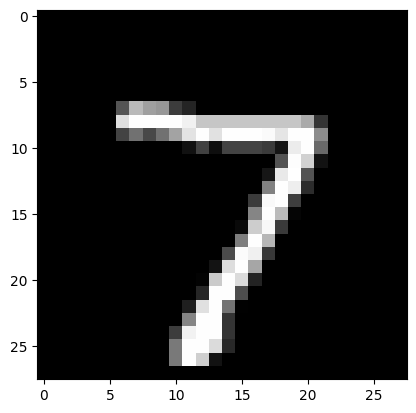

In [58]:
test_samples = enumerate(test_dataloader)
b_i, (sample_data, sample_targets) = next(test_samples)

# sample_data[0][0]

plt.imshow(sample_data[0][0], cmap='gray', interpolation = None)
plt.show()

In [59]:
model(sample_data.to(device)).data.max(1)[1][0]
# 모델이 예측한 값

tensor(7, device='cuda:0')

In [60]:
sample_targets[0]

tensor(7)

visualize filters

In [61]:
list(model.children())

[Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1)),
 Dropout2d(p=0, inplace=10),
 Dropout1d(p=0, inplace=25),
 Linear(in_features=4608, out_features=64, bias=True),
 Linear(in_features=64, out_features=10, bias=True)]

In [62]:
model_children_list = list(model.children())
convolution_layers = []
model_parameters = []

In [63]:
for i in range(len(model_children_list)):
    if type(model_children_list[i]) == nn.Conv2d:
        model_parameters.append(model_children_list[i].weight)
        convolution_layers.append(model_children_list[i])

In [64]:
model_parameters[0]

Parameter containing:
tensor([[[[-0.0445, -0.0677, -0.1934],
          [ 0.1037, -0.3629,  0.1647],
          [-0.2912, -0.3030, -0.3394]]],


        [[[ 0.2174, -0.1309,  0.0280],
          [-0.2744, -0.2756, -0.2651],
          [-0.1949, -0.2865,  0.1787]]],


        [[[-0.0963,  0.0952,  0.3088],
          [ 0.0555,  0.0493,  0.3499],
          [-0.1921,  0.0213, -0.2089]]],


        [[[ 0.2604,  0.2535, -0.4206],
          [ 0.3474,  0.1854,  0.0625],
          [ 0.1612,  0.3029, -0.0418]]],


        [[[-0.4297, -0.2376, -0.3832],
          [ 0.0907, -0.0468, -0.1825],
          [ 0.1199,  0.4209,  0.0637]]],


        [[[-0.0250, -0.1480, -0.0329],
          [ 0.3034,  0.2287,  0.1199],
          [ 0.1591,  0.1661,  0.0718]]],


        [[[ 0.0762, -0.2518, -0.3340],
          [ 0.3956,  0.0275, -0.4545],
          [ 0.1681,  0.3552, -0.2891]]],


        [[[-0.2418, -0.3170, -0.0803],
          [ 0.0092, -0.0546, -0.3255],
          [ 0.2711,  0.3783,  0.2698]]],


        [[

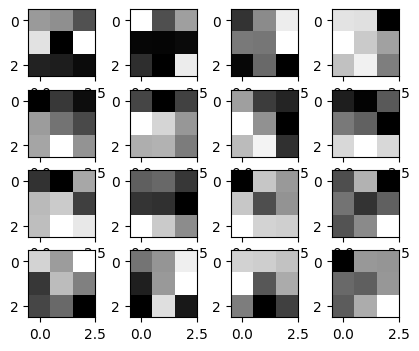

In [65]:
# 시각화
plt.figure(figsize=(5,4))
for i, flt in enumerate(model_parameters[0]):
    plt.subplot(4,4,i+1)
    plt.imshow(flt[0, :, :].detach().cpu(), cmap='gray')
    # plt.axis('off')
plt.savefig('filters.png')
plt.show()

# flt[0, :, :] : 흑백이라 채널 1개, 에기에 대응하는 가중치 슬라이스
# rgb면? flt[0, :, :] red채널 / flt[1, :, :] green채널 / flt[2, :, :] blue채널
# filter 구조 (출력 채널, 입력 채널, H, W)
# 0 : index 0 (첫번째 입력채널) 2d 가중치 행렬만 선택

feature map 시각화

In [66]:
convolution_layers

[Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1)),
 Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))]

In [67]:
convolution_layers[0]

Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))

In [70]:
per_layer_results = [convolution_layers[0](sample_data.to(device))]
# 첫번째 레이어 데티어를 넣어요 (주의 : device 설정 확인)

# per_layer_results[-1]   # 첫번째 레이어의 결과값

for i in range(1, len(convolution_layers)):
    max_input = per_layer_results[-1]
    per_layer_results.append(convolution_layers[i](max_input))

In [71]:
len(per_layer_results)

2

torch.Size([16, 26, 26])


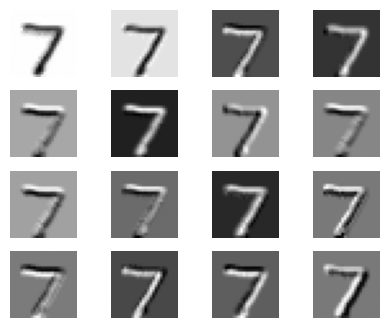

In [78]:
plt.figure(figsize=(5,4))

layer_visualisation = per_layer_results[0][0, :, :, :]
# per_layer_results[0] 첫번째 레이어(conv) 결과 텐서
# [0, :, :, :] 첫번째 이미지(index 0) 에 대한 데이터 선택
layer_visualisation = layer_visualisation.data
print(layer_visualisation.size())   # torch.Size([16, 26, 26]) 출력 채널, 높이, 너비

for i, flt in enumerate(layer_visualisation):
    plt.subplot(4,4,i+1)
    plt.imshow(flt.cpu(), cmap='gray')
    plt.axis('off')
plt.show()

torch.Size([32, 24, 24])


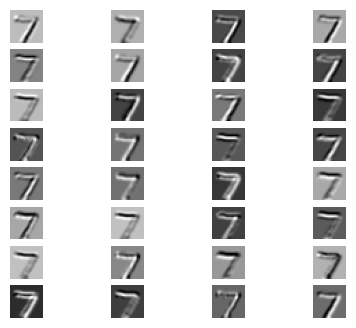

In [79]:
plt.figure(figsize=(5,4))

layer_visualisation = per_layer_results[1][0, :, :, :]
# per_layer_results[0] 첫번째 레이어(conv2) 결과 텐서
# [0, :, :, :] 첫번째 이미지(index 0) 에 대한 데이터 선택
layer_visualisation = layer_visualisation.data
print(layer_visualisation.size())   # torch.Size([16, 26, 26]) 출력 채널, 높이, 너비

for i, flt in enumerate(layer_visualisation):
    plt.subplot(8,4,i+1)
    plt.imshow(flt.cpu(), cmap='gray')
    plt.axis('off')
plt.show()